# Dual Steering Scratchpad

Iterate on the `additive_probe` and `dual_probe` path-steering modes from `README_NEW.md`.

The collaborator's commit (`bd8712e`) shipped only `__pycache__/*.pyc` for the dual-steering
implementation — no `.py` source, no Hydra configs, no on-disk artifacts. So instead of loading
real probe weights, this notebook builds a **synthetic toy**:

- 7 class centroids (mimicking weekdays) in a `D=64` "activation" space
- a no-bias multiclass linear probe trained on samples drawn around those centroids
- probe-softmax Fisher information at any point `h`
- skeleton functions for `additive_probe` and `dual_probe` (we'll fill these in together)
- a 2D PCA visualization of the steering trajectory + a target-class-probability trace

The function signatures match what `causalab/analyses/path_steering/path_mode.py` expects
(`build_path(start, end, n_steps, ...) -> Tensor`), so once the real source + subspace
artifacts land, plugging the same functions into the path-steering pipeline is a
search-and-replace on `start` / `end` centroids.

## Math recap (from `README_NEW.md`)

Let $h \in \mathbb{R}^D$ be a residual activation and $W \in \mathbb{R}^{C \times D}$ be the
no-bias multiclass linear probe (row $W_c$ is the weight vector for class $c$). The probe
softmax at $h$ is

$$
p_c(h) = \frac{\exp(W_c \cdot h)}{\sum_{c'} \exp(W_{c'} \cdot h)}.
$$

For source class $s$ and target class $t$, define the **class-difference direction**

$$
\beta := W_t - W_s \in \mathbb{R}^D.
$$

**`additive_probe`** is a raw-activation path along $\beta$:

```python
h_new = h + eta * beta
```

**`dual_probe`** is probe-softmax Fisher/Newton steering. Pick $\Sigma$ (the probe-softmax
Fisher information at $h$, or any positive-definite preconditioner — we'll experiment),
then solve a regularized system and take a unit step in the result:

```python
v = solve(Sigma + alpha * I, beta)
h_new = h + eta * v / ||v||
```

The Fisher of the softmax wrt $h$ is

$$
\Sigma(h) = W^\top \mathrm{diag}(p) W - W^\top p\, p^\top W
= \sum_c p_c W_c W_c^\top - \Big(\sum_c p_c W_c\Big)\Big(\sum_c p_c W_c\Big)^\top.
$$

A few things to think about as we iterate:
- **What should $\Sigma$ actually be?** Probe-Fisher (above)? Activation covariance over the
  training cloud? A blend? README calls it "probe-softmax Fisher/Newton steering" — but
  testing alternatives is part of the point.
- **Should we re-solve at every step** (true Newton) or only at $h_0$ (frozen preconditioner)?
- **Termination**: keep stepping until `p_t(h) >= target_prob` (e.g. 0.99), or fixed `n_steps`?
- **Comparison to `additive_probe`**: with $\Sigma = I$ we should recover (up to scaling +
  normalization) additive. So `dual_probe` reduces to `additive_probe` in that limit — useful
  sanity check.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import Tensor

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
print(f"device={DEVICE}  dtype={DTYPE}")

device=cpu  dtype=torch.float32


## 1. Synthetic activation cloud

7 classes (weekdays), each with a "true" centroid in $\mathbb{R}^{64}$. Class centroids are
placed on a (roughly) circular embedding to mimic the cyclic geometry the feature-geometry
analysis is designed to detect — but with isotropic Gaussian noise around each centroid so the
probe has something nontrivial to fit.

Knobs to play with:
- `D` — ambient dim
- `N_PER_CLASS` — samples per class
- `NOISE_STD` — anisotropy/spread of each class blob
- `CIRCLE_RADIUS` — how separated the centroids are (lower → harder probe problem)

In [2]:
D = 64
C = 7
N_PER_CLASS = 200
NOISE_STD = 0.6
CIRCLE_RADIUS = 3.0

CLASS_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def make_class_centroids(c: int, d: int, radius: float) -> Tensor:
    """Place ``c`` centroids on a circle in the first two axes of R^d, zero elsewhere.

    Embedding the cyclic class structure in only 2 of the D dims means a probe that ignores
    the other (D - 2) dims is optimal — easy to inspect, easy to fool with off-axis noise.
    """
    thetas = torch.linspace(0, 2 * math.pi, c + 1)[:-1]
    centroids = torch.zeros(c, d, dtype=DTYPE)
    centroids[:, 0] = radius * torch.cos(thetas)
    centroids[:, 1] = radius * torch.sin(thetas)
    return centroids


class_centroids = make_class_centroids(C, D, CIRCLE_RADIUS).to(DEVICE)

labels = torch.arange(C).repeat_interleave(N_PER_CLASS).to(DEVICE)
H = class_centroids[labels] + NOISE_STD * torch.randn(C * N_PER_CLASS, D, device=DEVICE)
print(f"activations H: shape={tuple(H.shape)}  labels: shape={tuple(labels.shape)}")
print(f"per-class centroid norms: {class_centroids.norm(dim=1).tolist()}")

activations H: shape=(1400, 64)  labels: shape=(1400,)
per-class centroid norms: [3.0, 3.0, 3.0, 2.999999761581421, 3.0, 3.0, 3.0]


## 2. Train a no-bias multiclass linear probe

`W : (C, D)` such that $\hat{y} = \mathrm{argmax}_c (W h)_c$. No bias term — matches what
`README_NEW.md` says about the feature-geometry probes.

The probe is trained with plain Adam on cross-entropy. We hold out 20% as a test set so we
can sanity-check that the probe actually learned a meaningful boundary before we start
trying to steer activations across it.

In [3]:
def train_probe(
    H: Tensor,
    y: Tensor,
    *,
    n_classes: int,
    n_steps: int = 2000,
    lr: float = 5e-2,
    weight_decay: float = 1e-4,
    test_frac: float = 0.2,
    verbose: bool = True,
) -> tuple[Tensor, dict]:
    """Fit a no-bias multiclass linear probe; return ``W`` and a small metrics dict."""
    n, d = H.shape
    rng = torch.Generator(device=H.device).manual_seed(SEED)
    perm = torch.randperm(n, generator=rng, device=H.device)
    n_test = int(test_frac * n)
    test_idx, train_idx = perm[:n_test], perm[n_test:]

    W = torch.zeros(n_classes, d, device=H.device, dtype=H.dtype, requires_grad=True)
    torch.nn.init.normal_(W, std=1.0 / math.sqrt(d))
    opt = torch.optim.Adam([W], lr=lr, weight_decay=weight_decay)

    for step in range(n_steps):
        logits = H[train_idx] @ W.T
        loss = F.cross_entropy(logits, y[train_idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        if verbose and step % 500 == 0:
            with torch.no_grad():
                train_acc = (logits.argmax(-1) == y[train_idx]).float().mean().item()
            print(f"  step={step:5d}  loss={loss.item():.4f}  train_acc={train_acc:.3f}")

    with torch.no_grad():
        train_acc = (H[train_idx] @ W.T).argmax(-1).eq(y[train_idx]).float().mean().item()
        test_acc = (H[test_idx] @ W.T).argmax(-1).eq(y[test_idx]).float().mean().item()
    metrics = {"train_acc": train_acc, "test_acc": test_acc, "n_train": len(train_idx), "n_test": len(test_idx)}
    return W.detach(), metrics


W, probe_metrics = train_probe(H, labels, n_classes=C)
print("\nProbe metrics:", probe_metrics)
print(f"W: shape={tuple(W.shape)}  norms_per_class={[round(v, 3) for v in W.norm(dim=1).tolist()]}")

  step=    0  loss=2.0084  train_acc=0.196


  step=  500  loss=0.0440  train_acc=1.000


  step= 1000  loss=0.0231  train_acc=1.000


  step= 1500  loss=0.0174  train_acc=1.000



Probe metrics: {'train_acc': 1.0, 'test_acc': 0.9321428537368774, 'n_train': 1120, 'n_test': 280}
W: shape=(7, 64)  norms_per_class=[8.189, 7.984, 8.13, 8.014, 7.766, 8.119, 8.165]


## 3. Math primitives

Three small building blocks both `additive_probe` and `dual_probe` will call into:

- `probe_softmax(h, W)` — class probabilities at `h`
- `class_diff(W, source, target)` — the $\beta = W_t - W_s$ direction
- `probe_fisher(h, W)` — the probe-softmax Fisher information matrix at `h`

Plus an alternate `activation_covariance(H)` so we can swap that in for `probe_fisher` and
see what changes.

In [4]:
def probe_softmax(h: Tensor, W: Tensor) -> Tensor:
    """Probe softmax. ``h: (..., D)``, ``W: (C, D)`` -> ``(..., C)``."""
    return F.softmax(h @ W.T, dim=-1)


def class_diff(W: Tensor, source: int, target: int) -> Tensor:
    """beta = W[target] - W[source]. Shape: (D,)."""
    return W[target] - W[source]


def probe_fisher(h: Tensor, W: Tensor) -> Tensor:
    """Fisher information of softmax(W h) w.r.t. h. Shape: (D, D).

    F(h) = W^T (diag(p) - p p^T) W
    """
    p = probe_softmax(h, W)  # (C,)
    Wp = W * p.unsqueeze(-1)  # (C, D)
    mean = Wp.sum(dim=0, keepdim=True)  # (1, D)
    return W.T @ Wp - mean.T @ mean  # (D, D)


def activation_covariance(H: Tensor) -> Tensor:
    """Sample covariance of the activation cloud. Shape: (D, D).

    Useful as an alternate preconditioner — sometimes called "data whitening" in steering.
    """
    Hc = H - H.mean(dim=0, keepdim=True)
    return Hc.T @ Hc / (H.shape[0] - 1)


h0 = class_centroids[0].clone()  # start at "Mon" centroid
p0 = probe_softmax(h0, W)
print("p(h0) =", {CLASS_NAMES[i]: round(p0[i].item(), 3) for i in range(C)})
print(f"argmax under probe: {CLASS_NAMES[p0.argmax().item()]}")
print()
beta_demo = class_diff(W, source=0, target=3)
F_demo = probe_fisher(h0, W)
Sigma_act = activation_covariance(H)
print(f"beta_demo (Mon->Thu): shape={tuple(beta_demo.shape)}  ||beta||={beta_demo.norm().item():.3f}")
print(f"probe_fisher(h0): shape={tuple(F_demo.shape)}  rank~={torch.linalg.matrix_rank(F_demo).item()}")
print(f"activation_cov:   shape={tuple(Sigma_act.shape)}  trace={Sigma_act.trace().item():.3f}")

p(h0) = {'Mon': 1.0, 'Tue': 0.0, 'Wed': 0.0, 'Thu': 0.0, 'Fri': 0.0, 'Sat': 0.0, 'Sun': 0.0}
argmax under probe: Mon

beta_demo (Mon->Thu): shape=(64,)  ||beta||=15.539
probe_fisher(h0): shape=(64, 64)  rank~=14
activation_cov:   shape=(64, 64)  trace=31.898


## 4. `additive_probe` — TODO (fill in together)

The README spec is just:

```python
beta = w_target - w_source
h_new = h + eta * beta   # repeated for n_steps
```

Things to decide as we implement:

- Should `eta` be a per-step amount, or do we spread a total budget across `n_steps`
  (so `eta_step = total_eta / n_steps`)? The latter matches how `_build_linear_path_kd`
  works in `causalab/analyses/path_steering/path_mode.py:97-117` (which builds a path of
  fixed length regardless of `n_steps`).
- Return signature should match `pm.build_path`: `(n_steps, D)` tensor of waypoints
  including the start `h0`. That way it slots into the same `collect_grid_distributions`
  call.

In [5]:
def additive_probe_path(
    h0: Tensor,
    W: Tensor,
    *,
    source: int,
    target: int,
    n_steps: int,
    eta: float = 0.1,
) -> Tensor:
    """Raw-activation path along beta = W[target] - W[source].

    Each step adds ``eta * beta`` to the previous waypoint. After ``n_steps``
    waypoints the total displacement from ``h0`` is ``(n_steps - 1) * eta * beta``.

    Args:
        h0: Starting activation, shape ``(D,)``.
        W: Probe weights, shape ``(C, D)``.
        source: Source class index.
        target: Target class index.
        n_steps: Number of waypoints in the returned path (including ``h0``).
        eta: Per-step displacement scale along ``beta``.

    Returns:
        Tensor of shape ``(n_steps, D)`` with ``path[0] == h0`` and
        ``path[k] == h0 + k * eta * beta``.
    """
    beta = class_diff(W, source, target)
    alphas = torch.arange(n_steps, device=h0.device, dtype=h0.dtype)
    return h0.unsqueeze(0) + (eta * alphas).unsqueeze(1) * beta.unsqueeze(0)

## 5. `dual_probe` — TODO (fill in together)

The README spec:

```python
v = solve(Sigma + alpha * I, beta)
h = h + eta * v / ||v||   # repeated until p[target] >= target_prob, or n_steps cap
```

Open design questions to discuss:

- **Choice of `Sigma`**: pass a callable `sigma_fn(h, W) -> (D, D)` so we can swap between
  `probe_fisher` (Newton-on-probe-NLL), `activation_covariance` (data whitening), or a
  constant frozen-at-`h0` Fisher.
- **Termination**: hit `target_prob` (typical 0.99 per README "Tune dual steering" example)
  vs fixed `n_steps`. README's example exposes both `eta` and `target_prob` as runtime
  config, so we should too.
- **Solve robustness**: `torch.linalg.solve` will explode if `Sigma + alpha*I` is
  ill-conditioned. We probably want `torch.linalg.cholesky_ex` + back-sub, or just
  fall back to `lstsq` with a big alpha.
- **Sanity property**: with `Sigma = 0` (or `alpha -> inf`), `v ∝ beta` so `dual_probe`
  should collapse onto `additive_probe / ||beta||`. Good unit test.

In [6]:
from typing import Callable


def _solve_pd(M: Tensor, b: Tensor) -> Tensor:
    """Solve ``M x = b`` for symmetric PD ``M``; Cholesky with LU fallback."""
    L, info = torch.linalg.cholesky_ex(M)
    if int(info.item()) == 0:
        return torch.cholesky_solve(b.unsqueeze(-1), L).squeeze(-1)
    return torch.linalg.solve(M, b)


def dual_probe_path(
    h0: Tensor,
    h_target: Tensor,
    W: Tensor,
    *,
    source: int,
    target: int,
    n_steps: int,
    eta: float = 1.0,
    alpha: float = 1e-2,
    target_prob: float | None = 0.99,
    target_tol: float | None = None,
    sigma_fn: Callable[[Tensor, Tensor], Tensor] | None = None,
) -> Tensor:
    """Discretize a dual-coordinate path and map it back to primal space.

    1. Build the source chart at ``h0``:

           M0 = Sigma(h0) + alpha I
           z_source = solve(M0, h0)
           z_target = solve(M0, h_target)

    2. Discretize the straight dual-space segment from ``z_source`` to
       ``z_target`` using ``n_steps`` waypoints.

    3. Map each dual waypoint ``z_k`` back to primal using the conditional
       covariance at the current primal point:

           M_k = Sigma(h_{k-1}) + alpha I
           h_k = M_k @ z_k

    The metric/charts therefore change with the current location, but the path
    being sampled is explicitly the straight segment in dual coordinates. This
    avoids the older mistake where we recomputed a local dual displacement and
    immediately mapped it back, which collapses to the primal centroid line.

    ``sigma_fn`` defaults to ``probe_fisher``, the probability-weighted covariance
    of probe rows conditioned on ``p(c | h)``.

    Args:
        h0: Starting activation centroid, shape ``(D,)``.
        h_target: Target activation centroid, shape ``(D,)``.
        W: Probe weights, shape ``(C, D)``.
        source: Source class index (kept for interface compatibility).
        target: Target class index.
        n_steps: Number of discrete dual waypoints to sample, including endpoints.
        eta: Fraction of the source-to-target dual segment to traverse. ``eta=1``
            reaches the target dual coordinate at the final waypoint; ``eta>1``
            oversteers beyond it.
        alpha: Tikhonov regularization weight on ``Sigma + alpha * I``.
        target_prob: Optional early-stop threshold on ``p[target]``.
        target_tol: Optional early-stop threshold on ``||h_target - h_curr||``.
        sigma_fn: ``(h, W) -> (D, D)`` conditional covariance. Defaults to
            ``probe_fisher``.

    Returns:
        Tensor of shape ``(k, D)`` with ``1 <= k <= n_steps`` and ``path[0] == h0``.
    """
    if sigma_fn is None:
        sigma_fn = probe_fisher

    I = torch.eye(h0.shape[0], device=h0.device, dtype=h0.dtype)
    M0 = sigma_fn(h0, W) + alpha * I
    z_source = _solve_pd(M0, h0)
    z_target = _solve_pd(M0, h_target)
    dual_delta = z_target - z_source

    # ``eta`` is now a path-length multiplier, not a per-step update size.
    # eta=1 samples source -> target; eta=1.5 overshoots 50% beyond target.
    alphas = torch.linspace(0.0, eta, n_steps, device=h0.device, dtype=h0.dtype)

    h_curr = h0.clone()
    waypoints = [h_curr.clone()]
    for a in alphas[1:]:
        if target_prob is not None and probe_softmax(h_curr, W)[target].item() >= target_prob:
            break
        if target_tol is not None and (h_target - h_curr).norm().item() <= target_tol:
            break

        z_curr = z_source + a * dual_delta
        M_curr = sigma_fn(h_curr, W) + alpha * I
        h_curr = M_curr @ z_curr
        waypoints.append(h_curr.clone())

    return torch.stack(waypoints)


def _activation_from_probe_probs(
    q: Tensor,
    W: Tensor,
    *,
    anchor: Tensor,
    ridge: float,
) -> Tensor:
    """Map a desired probe distribution back to an activation by ridge inversion.

    Softmax logits are defined up to an additive constant, so both sides are
    centered across classes before solving:

        (W - mean_class(W)) @ h ~= center(log q)

    The ridge term keeps the inverse well-posed and chooses the activation closest
    to ``anchor`` among the many possible solutions in D-dimensional space.
    """
    q = (q / q.sum()).clamp_min(1e-12)
    z = q.log()
    z = z - z.mean()

    A = W - W.mean(dim=0, keepdim=True)  # centered-logit linear map, shape (C, D)
    I = torch.eye(W.shape[1], device=W.device, dtype=W.dtype)
    rhs = A.T @ (z - A @ anchor)
    update = _solve_pd(A.T @ A + ridge * I, rhs)
    return anchor + update


def simplex_probe_path(
    h0: Tensor,
    h_target: Tensor,
    W: Tensor,
    *,
    source: int,
    target: int,
    n_steps: int,
    eta: float = 1.0,
    ridge: float = 1.0,
    eps: float = 1e-3,
    temperature: float = 3.0,
    pin_endpoints: bool = True,
) -> Tensor:
    """Interpolate in the probe probability simplex, then map back to activations.

    This is the explicitly probability-simplex version:

        q_source = softmax(W h0 / temperature)
        q_target = softmax(W h_target / temperature)
        q_k = normalize((1 - a_k) q_source + a_k q_target)
        h_k = argmin_h ||center(W h) - center(log q_k)||^2
                      + ridge * ||h - anchor_k||^2

    ``anchor_k`` is the primal centroid-linear interpolation at the same fraction,
    which selects a stable representative activation among the many activations
    that can realize similar probe probabilities.

    Args:
        h0: Starting activation centroid, shape ``(D,)``.
        h_target: Target activation centroid, shape ``(D,)``.
        W: Probe weights, shape ``(C, D)``.
        source: Source class index (kept for interface compatibility).
        target: Target class index (kept for interface compatibility).
        n_steps: Number of simplex waypoints, including endpoints.
        eta: Fraction of the simplex segment to traverse. Use ``eta=1`` for
            source -> target. Values above 1 extrapolate the anchor but the
            simplex probabilities are clamped/renormalized.
        ridge: Strength of the anchor regularizer in the inverse map. Larger
            values keep the recovered activation closer to the primal-linear anchor.
        eps: Minimum probability before taking logs. Larger values avoid huge
            target logits from near-one-hot probe probabilities.
        temperature: Softens endpoint probe probabilities before simplex
            interpolation. The toy probe is very overconfident, so temperature > 1
            prevents the inverse map from chasing extreme log-probability targets.
        pin_endpoints: If True, force the first waypoint to ``h0`` and, when
            ``eta == 1``, the final waypoint to ``h_target``. This avoids the
            inverse map moving the known primal centroids just because the simplex
            endpoints were softened for numerical stability.

    Returns:
        Tensor of shape ``(n_steps, D)``.
    """
    q_source = F.softmax((h0 @ W.T) / temperature, dim=-1)
    q_target = F.softmax((h_target @ W.T) / temperature, dim=-1)
    alphas = torch.linspace(0.0, eta, n_steps, device=h0.device, dtype=h0.dtype)

    waypoints = []
    for i, a in enumerate(alphas):
        # The source/target primal centroids are known exactly. The inverse map is
        # only needed for interior simplex points; otherwise temperature/ridge can
        # move endpoints away from the centroids we intentionally chose.
        if pin_endpoints and i == 0:
            waypoints.append(h0.clone())
            continue
        if pin_endpoints and abs(float(a.item()) - 1.0) < 1e-7:
            waypoints.append(h_target.clone())
            continue

        anchor = h0 + a * (h_target - h0)
        q = (1.0 - a) * q_source + a * q_target
        q = q.clamp_min(eps)
        q = q / q.sum()
        h = _activation_from_probe_probs(q, W, anchor=anchor, ridge=ridge)
        waypoints.append(h)
    return torch.stack(waypoints)


## 6. Visualize what's happening

A small driver that:

1. Picks `(source, target)` classes (default Mon -> Thu).
2. Calls `additive_probe_path` and `dual_probe_path`.
3. Plots target-class probability along the path (sanity check).
4. Plots the 2D PCA scatter of the activation cloud with both paths overlaid.

Skips gracefully if either path is still `NotImplementedError`, so you can run this cell
even before both TODOs are filled in.

In [7]:
@dataclass
class PathResult:
    label: str
    waypoints: Tensor  # (n_steps, D)


def try_path(fn, **kwargs) -> PathResult | None:
    """Call a path builder; return None (with a one-line note) if it's still NotImplemented."""
    try:
        wp = fn(**kwargs)
    except NotImplementedError:
        print(f"  {fn.__name__}: NotImplementedError (skipping)")
        return None
    n_waypoints, activation_dim = wp.shape
    print(f"  {fn.__name__}: {n_waypoints} waypoints in {activation_dim}D activation space")
    return PathResult(label=fn.__name__, waypoints=wp)


def plot_paths(
    paths: list[PathResult],
    *,
    source: int,
    target: int,
    dual_alpha: float = 1e-2,
    show_probe_directions: bool = True,
) -> None:
    """Show paths in primal/dual spaces plus one stacked simplex plot per path.

    Spaces:
    - primal: raw activation space, shown through PCA of activation samples.
    - dual-vector: convex combinations ``sum_c p(c|h) W_c`` of probe vectors.
    - simplex: the probability vector ``p(c|h)`` itself, shown as a stacked
      probability-mass decomposition per path.
    """
    paths = [p for p in paths if p is not None]
    cmap = plt.colormaps.get_cmap("hsv").resampled(C)
    day_colors = [cmap(c) for c in range(C)]

    n_cols = 2 + max(1, len(paths))
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), squeeze=False)
    axes = axes[0]

    # 2D PCA of the activation cloud, with overlaid paths.
    Hc = H - H.mean(dim=0, keepdim=True)
    _U, _S, Vh = torch.linalg.svd(Hc, full_matrices=False)
    proj = Vh[:2]  # (2, D)

    ax = axes[0]
    H_2d = (H @ proj.T).cpu().numpy()
    labels_np = labels.cpu().numpy()
    for c in range(C):
        mask = labels_np == c
        ax.scatter(
            H_2d[mask, 0],
            H_2d[mask, 1],
            s=8,
            alpha=0.3,
            color=day_colors[c],
            label=CLASS_NAMES[c],
        )
    centroids_2d = (class_centroids @ proj.T).cpu().numpy()
    ax.scatter(
        centroids_2d[:, 0],
        centroids_2d[:, 1],
        s=140,
        marker="X",
        c="black",
        linewidths=1,
        edgecolors="white",
        zorder=5,
    )

    for p in paths:
        path_2d = (p.waypoints @ proj.T).cpu().numpy()
        ax.plot(path_2d[:, 0], path_2d[:, 1], lw=2, label=p.label)
        ax.scatter(
            path_2d[[0, -1], 0],
            path_2d[[0, -1], 1],
            s=80,
            marker="o",
            edgecolors="black",
            zorder=6,
        )

    if show_probe_directions:
        source_anchor = class_centroids[source]
        anchor_2d = (source_anchor @ proj.T).detach().cpu().numpy()
        cloud_range = H_2d.max(axis=0) - H_2d.min(axis=0)
        arrow_len = 0.18 * float(np.linalg.norm(cloud_range))

        def draw_direction(direction: Tensor, label: str, *, color: str, alpha: float, zorder: int) -> None:
            direction_2d = (direction @ proj.T).detach().cpu().numpy()
            norm = float(np.linalg.norm(direction_2d))
            if norm < 1e-9:
                return
            dx, dy = arrow_len * direction_2d / norm
            ax.arrow(
                anchor_2d[0],
                anchor_2d[1],
                dx,
                dy,
                color=color,
                alpha=alpha,
                width=0.015 * arrow_len,
                head_width=0.07 * arrow_len,
                length_includes_head=True,
                zorder=zorder,
            )
            ax.text(
                anchor_2d[0] + 1.08 * dx,
                anchor_2d[1] + 1.08 * dy,
                label,
                color=color,
                fontsize=8,
                zorder=zorder,
            )

        beta = class_diff(W, source, target)
        draw_direction(beta, f"β target", color="black", alpha=0.95, zorder=9)

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title("Primal activation PCA")
    ax.legend(fontsize=8, loc="best")

    # Dual-vector space: each point is sum_c p(c|h) W_c.
    ax = axes[1]
    Wc = W - W.mean(dim=0, keepdim=True)
    _Uw, _Sw, Vhw = torch.linalg.svd(Wc, full_matrices=False)
    dual_proj = Vhw[:2]  # (2, D)
    W_2d = (W @ dual_proj.T).detach().cpu().numpy()

    for c in range(C):
        ax.scatter(
            W_2d[c, 0],
            W_2d[c, 1],
            s=140,
            marker="D",
            color=day_colors[c],
            edgecolors="black",
            zorder=5,
        )
        ax.text(W_2d[c, 0], W_2d[c, 1], f"  {CLASS_NAMES[c]}", color=day_colors[c], fontsize=9, zorder=6)

    for p in paths:
        probs = probe_softmax(p.waypoints, W)  # (n_steps, C)
        dual_points = probs @ W                # convex combination in R^D
        dual_2d = (dual_points @ dual_proj.T).detach().cpu().numpy()
        ax.plot(dual_2d[:, 0], dual_2d[:, 1], lw=2, marker="o", markersize=3, label=p.label)
        ax.scatter(dual_2d[[0, -1], 0], dual_2d[[0, -1], 1], s=80, marker="o", edgecolors="black", zorder=7)

    ax.set_xlabel("dual-vector PC 1")
    ax.set_ylabel("dual-vector PC 2")
    ax.set_title("Dual space: convex combinations of probes")
    ax.legend(fontsize=8, loc="best")
    ax.set_aspect("equal", adjustable="datalim")

    # Simplex coordinates: one stacked probability-mass plot per path.
    if paths:
        for path_idx, p in enumerate(paths):
            ax = axes[2 + path_idx]
            probs = probe_softmax(p.waypoints, W).detach().cpu().numpy()  # (n_steps, C)
            x = np.linspace(0.0, 1.0, probs.shape[0])
            ax.stackplot(x, probs.T, colors=day_colors, labels=CLASS_NAMES, alpha=0.9)
            ax.set_xlabel("trajectory fraction")
            ax.set_ylabel("probability mass")
            ax.set_title(f"Simplex mass: {p.label}")
            ax.set_ylim(0.0, 1.0)
            if path_idx == len(paths) - 1:
                ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
    else:
        axes[2].set_axis_off()

    fig.tight_layout()
    plt.show()


Running additive_probe_path...
  additive_probe_path: 6 waypoints in 64D activation space
Running simplex_probe_path...


  simplex_probe_path: 100 waypoints in 64D activation space
additive: ||h-mean(H)|| min/median/max = 1.33 / 2.33 / 5.22; step max = 1.55
simplex: ||h-mean(H)|| min/median/max = 1.51 / 1.56 / 3.00; step max = 2.80


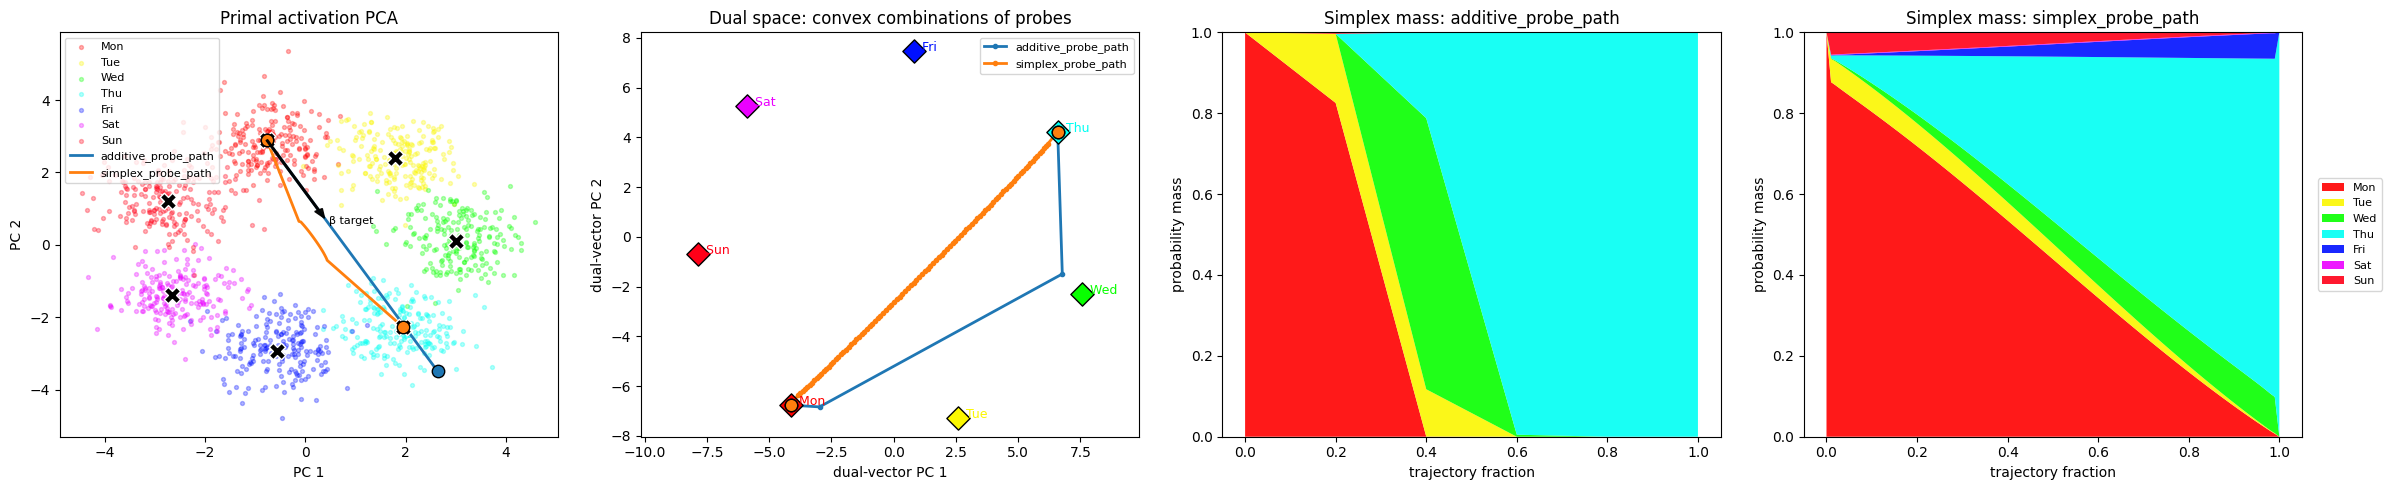

In [8]:
SOURCE, TARGET = 0, 3  # Mon -> Thu
h_start = class_centroids[SOURCE].clone()

ADDITIVE_N_STEPS = 6
ADDITIVE_ETA = 0.1

SIMPLEX_N_STEPS = 100
SIMPLEX_ETA = 1.0
SIMPLEX_RIDGE = 1.0
SIMPLEX_EPS = 1e-3
SIMPLEX_TEMPERATURE = 3.0

print("Running additive_probe_path...")
add_path = try_path(
    additive_probe_path,
    h0=h_start,
    W=W,
    source=SOURCE,
    target=TARGET,
    n_steps=ADDITIVE_N_STEPS,
    eta=ADDITIVE_ETA,
)
print("Running simplex_probe_path...")
simplex_path = try_path(
    simplex_probe_path,
    h0=h_start,
    h_target=class_centroids[TARGET],
    W=W,
    source=SOURCE,
    target=TARGET,
    n_steps=SIMPLEX_N_STEPS,
    eta=SIMPLEX_ETA,
    ridge=SIMPLEX_RIDGE,
    eps=SIMPLEX_EPS,
    temperature=SIMPLEX_TEMPERATURE,
    pin_endpoints=True,
)


def summarize_path_scale(name: str, result: PathResult | None) -> None:
    if result is None:
        return
    wp = result.waypoints
    dist_to_cloud_mean = (wp - H.mean(dim=0)).norm(dim=1)
    step_norms = (wp[1:] - wp[:-1]).norm(dim=1) if wp.shape[0] > 1 else torch.tensor([], device=wp.device)
    print(
        f"{name}: ||h-mean(H)|| min/median/max = "
        f"{dist_to_cloud_mean.min().item():.2f} / "
        f"{dist_to_cloud_mean.median().item():.2f} / "
        f"{dist_to_cloud_mean.max().item():.2f}; "
        f"step max = {step_norms.max().item() if len(step_norms) else 0:.2f}"
    )


summarize_path_scale("additive", add_path)
summarize_path_scale("simplex", simplex_path)
plot_paths([add_path, simplex_path], source=SOURCE, target=TARGET)


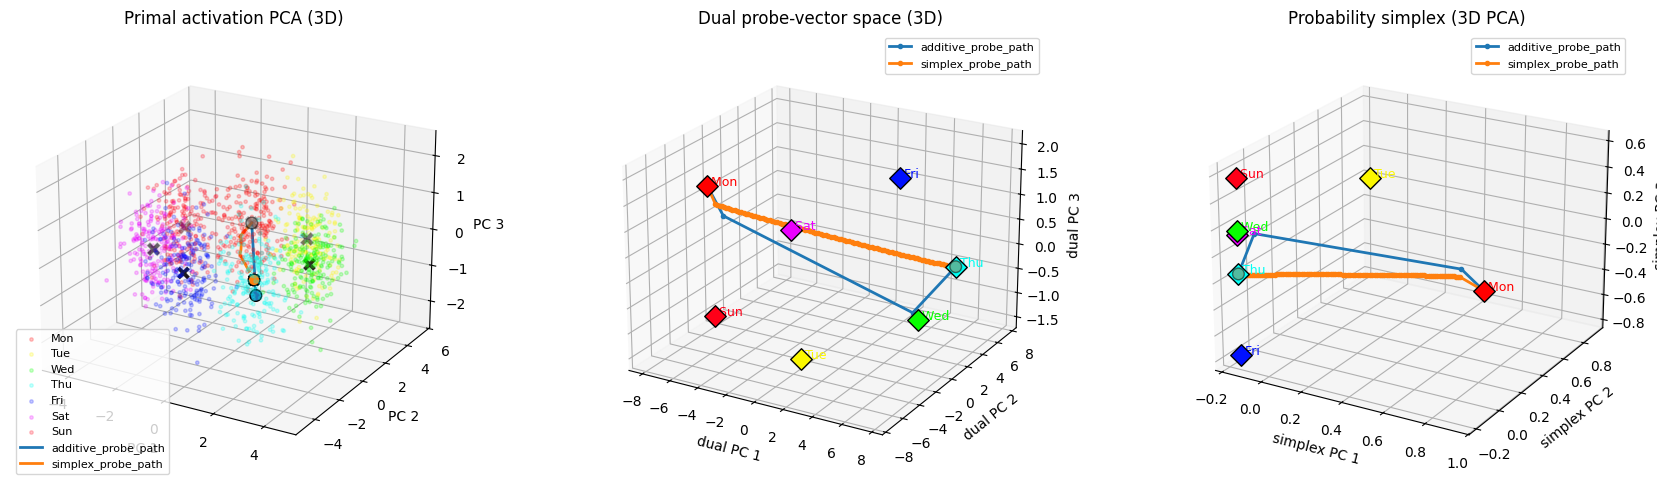

In [9]:
def plot_paths_3d(paths: list[PathResult], *, source: int, target: int) -> None:
    """Show trajectories in 3D projections of primal, dual-vector, and simplex spaces."""
    paths = [p for p in paths if p is not None]
    cmap = plt.colormaps.get_cmap("hsv").resampled(C)
    day_colors = [cmap(c) for c in range(C)]

    fig = plt.figure(figsize=(18, 5))
    axes = [fig.add_subplot(1, 3, i + 1, projection="3d") for i in range(3)]

    # 1. Primal activation space: PCA of activation cloud.
    Hc = H - H.mean(dim=0, keepdim=True)
    _U, _S, Vh = torch.linalg.svd(Hc, full_matrices=False)
    primal_proj = Vh[:3]
    H_3d = (H @ primal_proj.T).detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy()

    ax = axes[0]
    for c in range(C):
        mask = labels_np == c
        ax.scatter(
            H_3d[mask, 0],
            H_3d[mask, 1],
            H_3d[mask, 2],
            s=6,
            alpha=0.22,
            color=day_colors[c],
            label=CLASS_NAMES[c],
        )
    centroids_3d = (class_centroids @ primal_proj.T).detach().cpu().numpy()
    ax.scatter(
        centroids_3d[:, 0],
        centroids_3d[:, 1],
        centroids_3d[:, 2],
        s=110,
        marker="X",
        color="black",
        edgecolors="white",
        zorder=5,
    )
    for p in paths:
        path_3d = (p.waypoints @ primal_proj.T).detach().cpu().numpy()
        ax.plot(path_3d[:, 0], path_3d[:, 1], path_3d[:, 2], lw=2, label=p.label)
        ax.scatter(path_3d[[0, -1], 0], path_3d[[0, -1], 1], path_3d[[0, -1], 2], s=70, edgecolors="black")
    ax.set_title("Primal activation PCA (3D)")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")

    # 2. Dual-vector space: convex combinations of probe vectors.
    Wc = W - W.mean(dim=0, keepdim=True)
    _Uw, _Sw, Vhw = torch.linalg.svd(Wc, full_matrices=False)
    dual_proj = Vhw[:3]
    W_3d = (W @ dual_proj.T).detach().cpu().numpy()

    ax = axes[1]
    for c in range(C):
        ax.scatter(W_3d[c, 0], W_3d[c, 1], W_3d[c, 2], s=120, marker="D", color=day_colors[c], edgecolors="black")
        ax.text(W_3d[c, 0], W_3d[c, 1], W_3d[c, 2], f" {CLASS_NAMES[c]}", color=day_colors[c], fontsize=9)
    for p in paths:
        probs = probe_softmax(p.waypoints, W)
        dual_points = probs @ W
        dual_3d = (dual_points @ dual_proj.T).detach().cpu().numpy()
        ax.plot(dual_3d[:, 0], dual_3d[:, 1], dual_3d[:, 2], lw=2, marker="o", markersize=3, label=p.label)
        ax.scatter(dual_3d[[0, -1], 0], dual_3d[[0, -1], 1], dual_3d[[0, -1], 2], s=70, edgecolors="black")
    ax.set_title("Dual probe-vector space (3D)")
    ax.set_xlabel("dual PC 1")
    ax.set_ylabel("dual PC 2")
    ax.set_zlabel("dual PC 3")

    # 3. Simplex space: PCA projection of probability vectors themselves.
    eye = torch.eye(C, device=W.device, dtype=W.dtype)
    eye_centered = eye - eye.mean(dim=0, keepdim=True)
    _Us, _Ss, Vhs = torch.linalg.svd(eye_centered, full_matrices=False)
    simplex_proj = Vhs[:3]
    vertices_3d = (eye @ simplex_proj.T).detach().cpu().numpy()

    ax = axes[2]
    for c in range(C):
        ax.scatter(vertices_3d[c, 0], vertices_3d[c, 1], vertices_3d[c, 2], s=120, marker="D", color=day_colors[c], edgecolors="black")
        ax.text(vertices_3d[c, 0], vertices_3d[c, 1], vertices_3d[c, 2], f" {CLASS_NAMES[c]}", color=day_colors[c], fontsize=9)
    for p in paths:
        probs = probe_softmax(p.waypoints, W)
        simplex_3d = (probs @ simplex_proj.T).detach().cpu().numpy()
        ax.plot(simplex_3d[:, 0], simplex_3d[:, 1], simplex_3d[:, 2], lw=2, marker="o", markersize=3, label=p.label)
        ax.scatter(simplex_3d[[0, -1], 0], simplex_3d[[0, -1], 1], simplex_3d[[0, -1], 2], s=70, edgecolors="black")
    ax.set_title("Probability simplex (3D PCA)")
    ax.set_xlabel("simplex PC 1")
    ax.set_ylabel("simplex PC 2")
    ax.set_zlabel("simplex PC 3")

    for ax in axes:
        ax.legend(fontsize=8, loc="best")
        ax.view_init(elev=22, azim=-60)

    fig.tight_layout()
    plt.show()


plot_paths_3d([add_path, simplex_path], source=SOURCE, target=TARGET)

## 7. Adjacent Weekday Transitions

Now look at the whole local cycle: `Mon→Tue`, `Tue→Wed`, ..., `Sun→Mon`.

For each adjacent pair we build two trajectories:

- **`primal_linear`**: straight interpolation between the two primal activation centroids.
- **`simplex_dual`**: interpolate between the two endpoint probe distributions in simplex space, then map each simplex waypoint back to a primal activation with the ridge inverse.

The plot below shows both trajectory families in:

1. **Primal activation space** (3D PCA of activations)
2. **Dual probe-vector space** (3D PCA of convex combinations `sum_c p(c|h) W_c`)

Colors identify the weekday transition; line style identifies the trajectory family.

In [10]:
@dataclass
class TransitionPath:
    label: str
    source: int
    target: int
    kind: str
    waypoints: Tensor


def primal_linear_path(h0: Tensor, h_target: Tensor, *, n_steps: int, eta: float = 1.0) -> Tensor:
    """Straight interpolation between primal centroids; eta=1 reaches target."""
    alphas = torch.linspace(0.0, eta, n_steps, device=h0.device, dtype=h0.dtype)
    return h0.unsqueeze(0) + alphas.unsqueeze(1) * (h_target - h0).unsqueeze(0)


def build_adjacent_weekday_paths(
    *,
    n_primal_steps: int = 40,
    n_simplex_steps: int = 40,
    simplex_ridge: float = 1.0,
    simplex_eps: float = 1e-3,
    simplex_temperature: float = 3.0,
) -> list[TransitionPath]:
    paths: list[TransitionPath] = []
    for source in range(C):
        target = (source + 1) % C
        label = f"{CLASS_NAMES[source]}→{CLASS_NAMES[target]}"
        h0 = class_centroids[source]
        h1 = class_centroids[target]

        paths.append(
            TransitionPath(
                label=label,
                source=source,
                target=target,
                kind="primal_linear",
                waypoints=primal_linear_path(h0, h1, n_steps=n_primal_steps, eta=1.0),
            )
        )
        paths.append(
            TransitionPath(
                label=label,
                source=source,
                target=target,
                kind="simplex_dual",
                waypoints=simplex_probe_path(
                    h0,
                    h1,
                    W,
                    source=source,
                    target=target,
                    n_steps=n_simplex_steps,
                    eta=1.0,
                    ridge=simplex_ridge,
                    eps=simplex_eps,
                    temperature=simplex_temperature,
                    pin_endpoints=True,
                ),
            )
        )
    return paths


adjacent_paths = build_adjacent_weekday_paths(
    n_primal_steps=40,
    n_simplex_steps=40,
    simplex_ridge=SIMPLEX_RIDGE,
    simplex_eps=SIMPLEX_EPS,
    simplex_temperature=SIMPLEX_TEMPERATURE,
)
print(f"built {len(adjacent_paths)} paths ({C} transitions × 2 path types)")

built 14 paths (7 transitions × 2 path types)


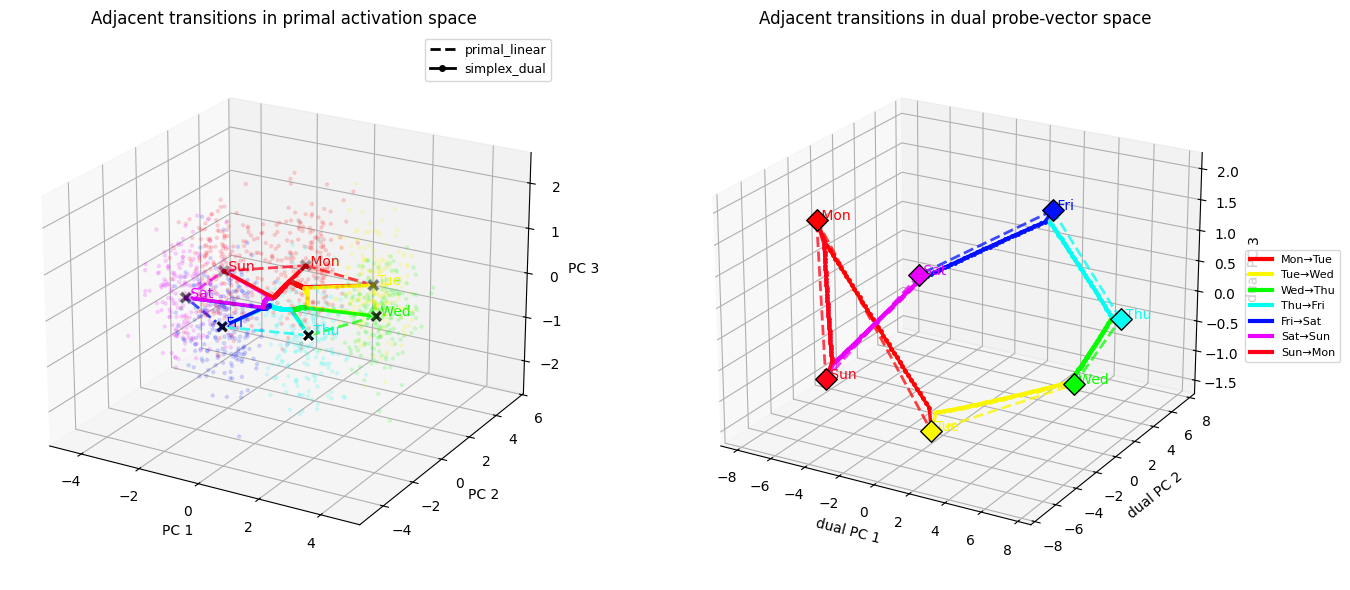

In [11]:
def plot_adjacent_transitions_3d(paths: list[TransitionPath]) -> None:
    """Plot adjacent weekday transitions in primal and dual-vector spaces."""
    cmap = plt.colormaps.get_cmap("hsv").resampled(C)
    transition_colors = [cmap(i) for i in range(C)]
    kind_styles = {
        "primal_linear": {"linestyle": "--", "marker": None, "lw": 2.0, "alpha": 0.75},
        "simplex_dual": {"linestyle": "-", "marker": "o", "lw": 2.5, "alpha": 0.95},
    }

    fig = plt.figure(figsize=(15, 6))
    axes = [fig.add_subplot(1, 2, i + 1, projection="3d") for i in range(2)]

    # Shared 3D projection for primal activation space.
    Hc = H - H.mean(dim=0, keepdim=True)
    _U, _S, Vh = torch.linalg.svd(Hc, full_matrices=False)
    primal_proj = Vh[:3]
    H_3d = (H @ primal_proj.T).detach().cpu().numpy()
    centroids_3d = (class_centroids @ primal_proj.T).detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy()

    ax = axes[0]
    for ci in range(C):
        mask = labels_np == ci
        ax.scatter(
            H_3d[mask, 0],
            H_3d[mask, 1],
            H_3d[mask, 2],
            s=5,
            alpha=0.12,
            color=transition_colors[ci],
        )
        ax.text(
            centroids_3d[ci, 0],
            centroids_3d[ci, 1],
            centroids_3d[ci, 2],
            f" {CLASS_NAMES[ci]}",
            color=transition_colors[ci],
            fontsize=10,
        )
    ax.scatter(
        centroids_3d[:, 0],
        centroids_3d[:, 1],
        centroids_3d[:, 2],
        s=90,
        marker="X",
        color="black",
        edgecolors="white",
        zorder=5,
    )
    for path in paths:
        style = kind_styles[path.kind]
        pts = (path.waypoints @ primal_proj.T).detach().cpu().numpy()
        ax.plot(
            pts[:, 0],
            pts[:, 1],
            pts[:, 2],
            color=transition_colors[path.source],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=2.5 if style["marker"] else 0,
            lw=style["lw"],
            alpha=style["alpha"],
        )
    ax.set_title("Adjacent transitions in primal activation space")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")

    # Shared 3D projection for dual-vector space.
    Wc = W - W.mean(dim=0, keepdim=True)
    _Uw, _Sw, Vhw = torch.linalg.svd(Wc, full_matrices=False)
    dual_proj = Vhw[:3]
    W_3d = (W @ dual_proj.T).detach().cpu().numpy()

    ax = axes[1]
    for ci in range(C):
        ax.scatter(
            W_3d[ci, 0],
            W_3d[ci, 1],
            W_3d[ci, 2],
            s=120,
            marker="D",
            color=transition_colors[ci],
            edgecolors="black",
            zorder=5,
        )
        ax.text(W_3d[ci, 0], W_3d[ci, 1], W_3d[ci, 2], f" {CLASS_NAMES[ci]}", color=transition_colors[ci], fontsize=10)
    for path in paths:
        style = kind_styles[path.kind]
        probs = probe_softmax(path.waypoints, W)
        dual_points = probs @ W
        pts = (dual_points @ dual_proj.T).detach().cpu().numpy()
        ax.plot(
            pts[:, 0],
            pts[:, 1],
            pts[:, 2],
            color=transition_colors[path.source],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=2.5 if style["marker"] else 0,
            lw=style["lw"],
            alpha=style["alpha"],
        )
    ax.set_title("Adjacent transitions in dual probe-vector space")
    ax.set_xlabel("dual PC 1")
    ax.set_ylabel("dual PC 2")
    ax.set_zlabel("dual PC 3")

    # Compact legends: one for colors, one for line styles.
    color_handles = [
        plt.Line2D([0], [0], color=transition_colors[i], lw=3, label=f"{CLASS_NAMES[i]}→{CLASS_NAMES[(i + 1) % C]}")
        for i in range(C)
    ]
    style_handles = [
        plt.Line2D([0], [0], color="black", linestyle="--", lw=2, label="primal_linear"),
        plt.Line2D([0], [0], color="black", linestyle="-", marker="o", lw=2, markersize=4, label="simplex_dual"),
    ]
    axes[0].legend(handles=style_handles, fontsize=9, loc="best")
    axes[1].legend(handles=color_handles, fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))

    for ax in axes:
        ax.view_init(elev=22, azim=-60)

    fig.tight_layout()
    plt.show()


plot_adjacent_transitions_3d(adjacent_paths)

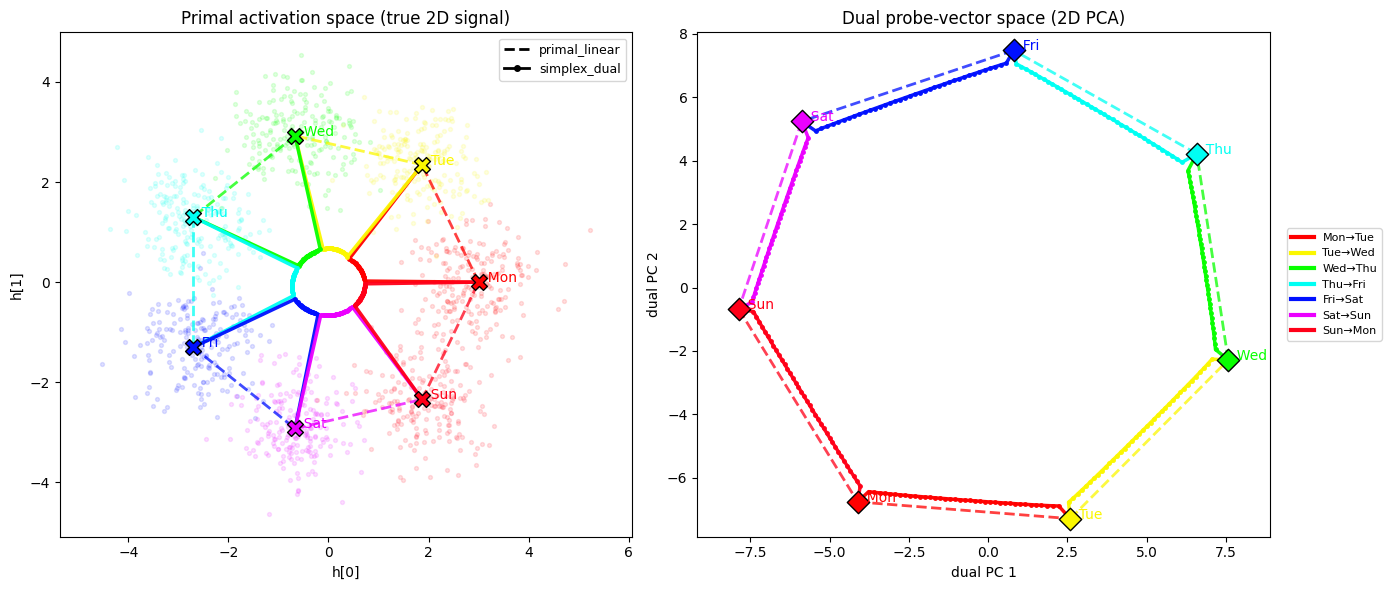

In [12]:
def plot_adjacent_transitions_2d(paths: list[TransitionPath]) -> None:
    """2D view of adjacent weekday transitions in primal and dual-vector spaces."""
    cmap = plt.colormaps.get_cmap("hsv").resampled(C)
    transition_colors = [cmap(i) for i in range(C)]
    kind_styles = {
        "primal_linear": {"linestyle": "--", "marker": None, "lw": 2.0, "alpha": 0.75},
        "simplex_dual": {"linestyle": "-", "marker": "o", "lw": 2.5, "alpha": 0.95},
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Primal: direct first two activation coordinates, since the signal is built there.
    ax = axes[0]
    H_np = H.detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy()
    cent_np = class_centroids.detach().cpu().numpy()
    for ci in range(C):
        mask = labels_np == ci
        ax.scatter(H_np[mask, 0], H_np[mask, 1], s=8, alpha=0.12, color=transition_colors[ci])
        ax.scatter(cent_np[ci, 0], cent_np[ci, 1], s=130, marker="X", color=transition_colors[ci], edgecolors="black", zorder=5)
        ax.text(cent_np[ci, 0], cent_np[ci, 1], f"  {CLASS_NAMES[ci]}", color=transition_colors[ci], fontsize=10, zorder=6)
    for path in paths:
        style = kind_styles[path.kind]
        pts = path.waypoints.detach().cpu().numpy()
        ax.plot(
            pts[:, 0],
            pts[:, 1],
            color=transition_colors[path.source],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=2.5 if style["marker"] else 0,
            lw=style["lw"],
            alpha=style["alpha"],
        )
    ax.set_title("Primal activation space (true 2D signal)")
    ax.set_xlabel("h[0]")
    ax.set_ylabel("h[1]")
    ax.set_aspect("equal", adjustable="datalim")

    # Dual-vector: PCA of probe vectors into 2D.
    ax = axes[1]
    Wc = W - W.mean(dim=0, keepdim=True)
    _Uw, _Sw, Vhw = torch.linalg.svd(Wc, full_matrices=False)
    dual_proj = Vhw[:2]
    W_2d = (W @ dual_proj.T).detach().cpu().numpy()
    for ci in range(C):
        ax.scatter(W_2d[ci, 0], W_2d[ci, 1], s=130, marker="D", color=transition_colors[ci], edgecolors="black", zorder=5)
        ax.text(W_2d[ci, 0], W_2d[ci, 1], f"  {CLASS_NAMES[ci]}", color=transition_colors[ci], fontsize=10, zorder=6)
    for path in paths:
        style = kind_styles[path.kind]
        probs = probe_softmax(path.waypoints, W)
        dual_points = probs @ W
        pts = (dual_points @ dual_proj.T).detach().cpu().numpy()
        ax.plot(
            pts[:, 0],
            pts[:, 1],
            color=transition_colors[path.source],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=2.5 if style["marker"] else 0,
            lw=style["lw"],
            alpha=style["alpha"],
        )
    ax.set_title("Dual probe-vector space (2D PCA)")
    ax.set_xlabel("dual PC 1")
    ax.set_ylabel("dual PC 2")
    ax.set_aspect("equal", adjustable="datalim")

    style_handles = [
        plt.Line2D([0], [0], color="black", linestyle="--", lw=2, label="primal_linear"),
        plt.Line2D([0], [0], color="black", linestyle="-", marker="o", lw=2, markersize=4, label="simplex_dual"),
    ]
    color_handles = [
        plt.Line2D([0], [0], color=transition_colors[i], lw=3, label=f"{CLASS_NAMES[i]}→{CLASS_NAMES[(i + 1) % C]}")
        for i in range(C)
    ]
    axes[0].legend(handles=style_handles, fontsize=9, loc="best")
    axes[1].legend(handles=color_handles, fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))

    fig.tight_layout()
    plt.show()


plot_adjacent_transitions_2d(adjacent_paths)

## Adjacent Transition Mass Transfer Examples

The `simplex_dual` paths are built by moving probability mass from the source class to the target class, then mapping those simplex waypoints back into activation space.

If the midpoint has substantial mass on both days (e.g. roughly `Mon=0.5`, `Tue=0.5`), the inverse map often lands near a decision-boundary or mixed-evidence region. In the synthetic primal ring, that can appear as the path moving inward toward the middle, then back outward to the target centroid.

The plots below show a few adjacent transitions as stacked probability mass over trajectory fraction.

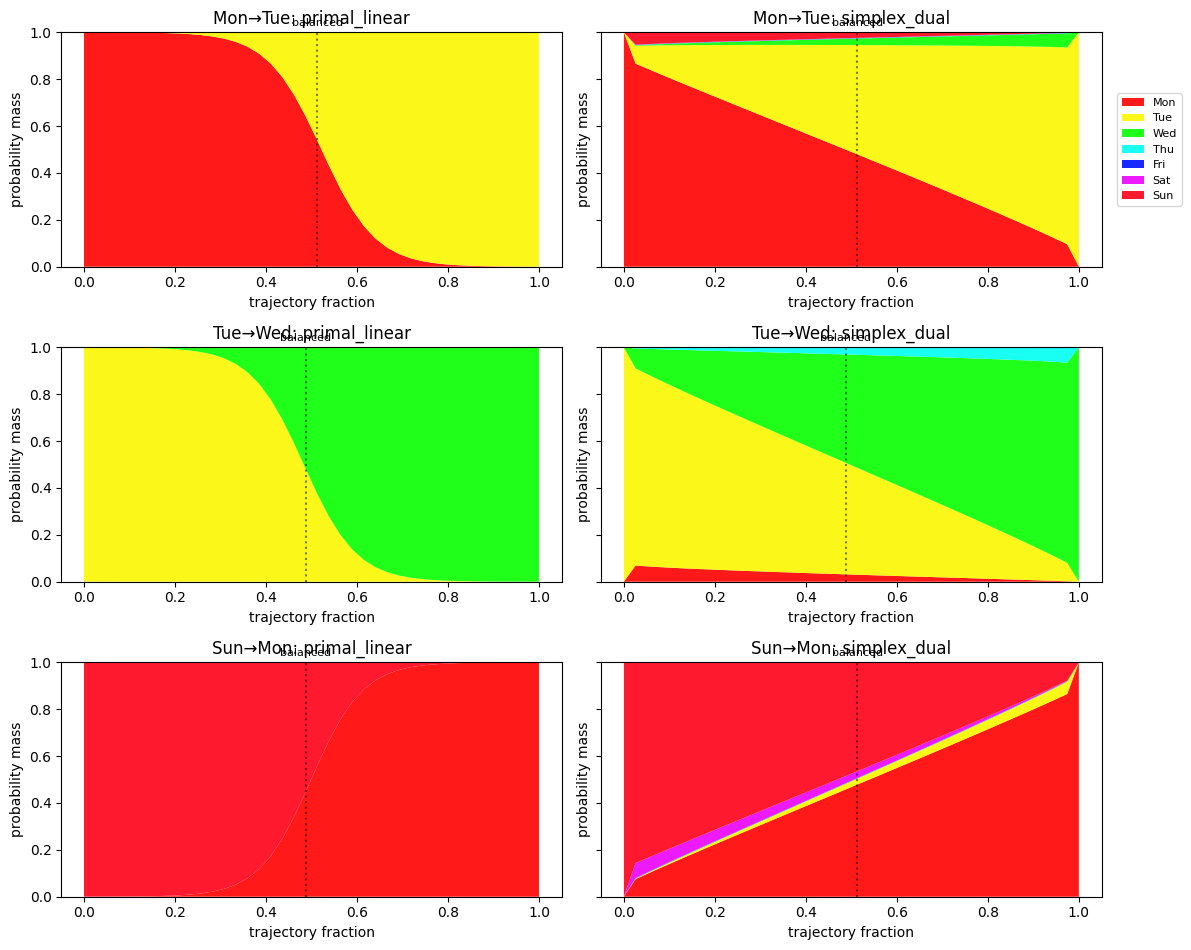

In [13]:
def plot_adjacent_mass_transfer_examples(
    paths: list[TransitionPath],
    *,
    sources: list[int] | None = None,
) -> None:
    """Stacked probability-mass examples for selected adjacent transitions."""
    if sources is None:
        sources = [0, 1, 6]  # Mon→Tue, Tue→Wed, Sun→Mon

    cmap = plt.colormaps.get_cmap("hsv").resampled(C)
    day_colors = [cmap(i) for i in range(C)]

    fig, axes = plt.subplots(
        len(sources),
        2,
        figsize=(12, 3.2 * len(sources)),
        sharex=False,
        sharey=True,
        squeeze=False,
    )

    for row, source in enumerate(sources):
        target = (source + 1) % C
        transition_label = f"{CLASS_NAMES[source]}→{CLASS_NAMES[target]}"
        for col, kind in enumerate(["primal_linear", "simplex_dual"]):
            ax = axes[row, col]
            matches = [p for p in paths if p.source == source and p.target == target and p.kind == kind]
            if not matches:
                ax.set_axis_off()
                continue
            path = matches[0]
            probs = probe_softmax(path.waypoints, W).detach().cpu().numpy()
            x = np.linspace(0.0, 1.0, probs.shape[0])
            ax.stackplot(x, probs.T, colors=day_colors, labels=CLASS_NAMES, alpha=0.9)
            ax.set_title(f"{transition_label}: {kind}")
            ax.set_xlabel("trajectory fraction")
            ax.set_ylabel("probability mass")
            ax.set_ylim(0.0, 1.0)
            # Mark the most mixed point for source/target mass, useful for seeing
            # where the activation path tends to move inward on the ring.
            mixed_idx = int(np.argmin(np.abs(probs[:, source] - probs[:, target])))
            ax.axvline(x[mixed_idx], color="black", linestyle=":", alpha=0.5)
            ax.text(
                x[mixed_idx],
                1.02,
                "balanced",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=0,
            )

    axes[0, -1].legend(
        CLASS_NAMES,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
    )
    fig.tight_layout()
    plt.show()


plot_adjacent_mass_transfer_examples(adjacent_paths, sources=[0, 1, 6])

## 7. Once we have real source + artifacts

When Haojing pushes the actual `dual_steering.py` / `probes.py` / feature-geometry analysis,
and you've run `subspace` for at least one task/model, the swap-in points are:

1. Replace the synthetic `class_centroids` / `H` / `labels` with the contents of the real
   subspace artifacts:

   ```python
   from safetensors.torch import load_file
   root = "artifacts/<task>/<model>/<variant>/subspace/pca_k64/<target_var>/layer_x_pos/L<layer>_<pos>"
   pca_feats = load_file(f"{root}/features/training_features.safetensors")["features"]
   raw_feats = load_file(f"{root}/features/raw_features.safetensors")["features"]
   ```

   `raw_feats` is the right input for our notebook's `H` (we want activations, not the
   PCA-reduced version, because that's what `path_steering`'s `additive_probe` /
   `dual_probe` modes operate on per `README_NEW.md:108-109`).

2. Replace `train_probe(...)` with `load_file(".../activation/probe.safetensors")` —
   should produce `W: (C, D)` with the same semantics.

3. Replace `class_centroids[SOURCE]` with the real raw-space centroid (mean of `raw_feats`
   rows whose label is `SOURCE` — exactly what `path_steering/main.py:543-561` computes).

4. Drop both `additive_probe_path` / `dual_probe_path` into a new `PathMode` in
   `causalab/analyses/path_steering/path_mode.py` (or session-local
   `code/methods/dual_steering.py` if we're still iterating).

For now: focus on getting the math right on the toy.